# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:**  Varun S G <br>
**`Roll Number`:**  U20230015 <br>
**`GitHub Branch`:** varun_U20230015  

# Imports and Setup

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from rlcmab_sampler import sampler


# Load Datasets

In [83]:
_news = pd.read_csv("data/news_articles.csv")
_train = pd.read_csv("data/train_users.csv")

print("=== News Articles (first 3 rows) ===")
display(_news.head(3))

print("\n=== Train Users (first 3 rows) ===")
display(_train.head(3))

=== News Articles (first 3 rows) ===


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23



=== Train Users (first 3 rows) ===


,user_id,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,...,screen_brightness,battery_percentage,cart_abandonment_count,browser_version,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber,label
0,U7392,NaN,23053,10,500.00,17.34,0.36661,37.29781,3,187.44,...,4.0,2.0,8,3.17.97,10,22.75,8.0,Z999,False,user_3
1,U2702,56.0,20239,11,913.33,22.22,0.61370,59.36342,5,145.15,...,4.5,63.0,5,1.57.10,8,1.75,4.0,U428,True,user_2
2,U2461,NaN,13907,9,1252.62,41.57,0.80368,76.78706,7,282.03,...,1.3,22.0,2,2.16.94,12,29.33,18.0,Z999,True,user_3


## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [84]:
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print("Raw shapes:")
print(f"  news_articles : {news_df.shape}")
print(f"  train_users   : {train_users.shape}")
print(f"  test_users    : {test_users.shape}")

#  Clean news articles
print("\nMissing values in news_articles:")
print(news_df.isnull().sum())

news_df = news_df.dropna(subset=["headline"])
news_df["short_description"] = news_df["short_description"].fillna("")
news_df["authors"] = news_df["authors"].fillna("")
print(f"\nNews articles after cleaning: {news_df.shape}")

# Filter to the 4 bandit categories
bandit_categories = ["ENTERTAINMENT", "EDUCATION", "TECH", "CRIME"]
news_filtered = news_df[news_df["category"].isin(bandit_categories)].copy()
news_filtered.reset_index(drop=True, inplace=True)
print(f"\nFiltered news articles (4 categories): {news_filtered.shape}")
print(news_filtered["category"].value_counts())

# Clean user datasets 
print("\nMissing values in train_users:")
missing_train = train_users.isnull().sum()
print(missing_train[missing_train > 0])

print("\nMissing values in test_users:")
missing_test = test_users.isnull().sum()
print(missing_test[missing_test > 0])

# Fill missing 'age' with the median
age_median = train_users["age"].median()
train_users["age"] = train_users["age"].fillna(age_median)
test_users["age"] = test_users["age"].fillna(age_median)
print(f"\nFilled missing age with median = {age_median}")

# Encode categorical / non-numeric columns 
# subscriber: bool -> int
train_users["subscriber"] = train_users["subscriber"].astype(int)
test_users["subscriber"] = test_users["subscriber"].astype(int)

# region_code: label encode
region_encoder = LabelEncoder()
train_users["region_code"] = region_encoder.fit_transform(train_users["region_code"])
test_users["region_code"] = test_users["region_code"].apply(
    lambda x: region_encoder.transform([x])[0] if x in region_encoder.classes_ else -1
)

# Drop non-numeric columns that can't be used as features
drop_cols = ["user_id", "browser_version"]
train_users = train_users.drop(columns=drop_cols)
test_users = test_users.drop(columns=drop_cols)

# Encode user labels 
label_mapping = {"user_1": "User1", "user_2": "User2", "user_3": "User3"}
train_users["label"] = train_users["label"].map(label_mapping)

user_label_encoder = LabelEncoder()
user_label_encoder.fit(["User1", "User2", "User3"])
train_users["label_encoded"] = user_label_encoder.transform(train_users["label"])

print("\nLabel encoding:")
for cls, code in zip(user_label_encoder.classes_, user_label_encoder.transform(user_label_encoder.classes_)):
    print(f"  {cls} -> {code}")

# Define feature columns (all numeric columns except label) 
feature_cols = [c for c in train_users.columns if c not in ["label", "label_encoded"]]
print(f"\nUsing {len(feature_cols)} features: {feature_cols}")

# Scale features
scaler = StandardScaler()
train_users[feature_cols] = scaler.fit_transform(train_users[feature_cols])
test_users[feature_cols] = scaler.transform(test_users[feature_cols])

print(f"\nClass distribution (train):\n{train_users['label'].value_counts()}")
print("\nPreprocessed train_users sample:")
train_users.head()

Raw shapes:
  news_articles : (209527, 6)
  train_users   : (2000, 33)
  test_users    : (2000, 32)

Missing values in news_articles:
link                     0
headline                 6
category                 0
short_description    19712
authors              37418
date                     0
dtype: int64

News articles after cleaning: (209521, 6)

Filtered news articles (4 categories): (24042, 6)
category
ENTERTAINMENT    17362
CRIME             3562
TECH              2104
EDUCATION         1014
Name: count, dtype: int64

Missing values in train_users:
age    698
dtype: int64

Missing values in test_users:
age    679
dtype: int64

Filled missing age with median = 39.0

Label encoding:
  User1 -> 0
  User2 -> 1
  User3 -> 2

Using 30 features: ['age', 'income', 'clicks', 'purchase_amount', 'session_duration', 'content_variety', 'engagement_score', 'num_transactions', 'avg_monthly_spend', 'avg_cart_value', 'browsing_depth', 'revisit_rate', 'scroll_activity', 'time_on_site', 'interacti

,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,avg_cart_value,...,screen_brightness,battery_percentage,cart_abandonment_count,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber,label,label_encoded
0,-0.016085,0.220907,-0.159472,-0.425788,-0.672161,-0.510518,-0.489356,-1.178934,-0.415620,-0.278104,...,0.855124,-1.777004,1.288363,0.157255,0.896136,-0.892810,1.159752,-0.620517,User3,2
1,1.831565,-0.196687,0.143707,0.070072,-0.457787,0.501072,0.408398,-0.397924,-0.517824,0.089112,...,1.308939,0.425341,-0.023170,-0.421420,-1.561229,-1.109059,0.410699,1.611559,User2,1
2,-0.016085,-1.136348,-0.462651,0.477108,0.392242,1.278852,1.117290,0.383085,-0.187022,-0.055289,...,-1.595477,-1.054923,-1.334704,0.735930,1.666110,-0.352188,1.159752,1.611559,User3,2
3,-0.016085,0.749504,0.446886,-0.425788,-0.108550,-0.926551,-0.778362,1.554599,-0.396504,-0.784117,...,1.036650,0.930798,1.725541,-1.578771,0.762736,-0.135939,0.724491,-0.620517,User3,2
4,-0.776883,0.948804,0.750065,-0.425788,1.433362,-0.521817,-0.496528,-0.397924,0.193975,-0.605558,...,1.399702,-0.766091,1.725541,-0.710758,-0.879018,1.485927,0.119681,-0.620517,User1,0


## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


Train size: 1600, Validation size: 400

User Classification Accuracy (validation set): 0.9025

Classification Report:
              precision    recall  f1-score   support

       User1       0.90      0.86      0.88       142
       User2       0.97      0.88      0.92       142
       User3       0.84      0.98      0.90       116

    accuracy                           0.90       400
   macro avg       0.90      0.91      0.90       400
weighted avg       0.91      0.90      0.90       400

Confusion Matrix:
[[122   2  18]
 [ 13 125   4]
 [  0   2 114]]


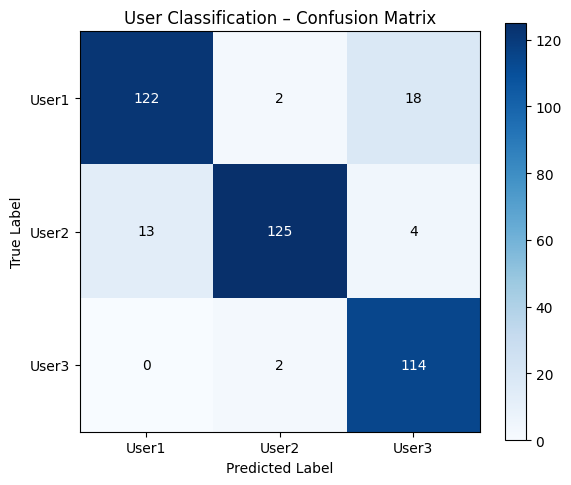

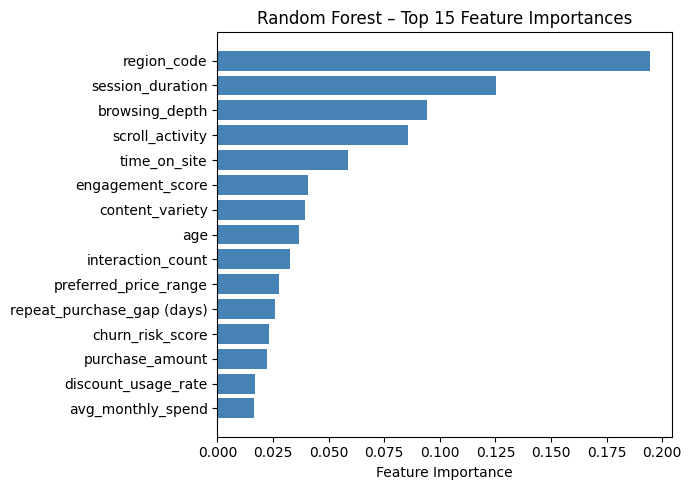

Retrained classifier on full training data for bandit sections.


In [85]:
X_all = train_users[feature_cols].values
y_all = train_users["label_encoded"].values

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}")

clf = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_val)
val_accuracy = accuracy_score(y_val, y_pred)

print(f"\nUser Classification Accuracy (validation set): {val_accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=user_label_encoder.classes_))

cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(cm.shape[1]),
    yticks=np.arange(cm.shape[0]),
    xticklabels=user_label_encoder.classes_,
    yticklabels=user_label_encoder.classes_,
    ylabel="True Label",
    xlabel="Predicted Label",
    title="User Classification – Confusion Matrix",
)
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

# Feature importance (top 15)
importances = clf.feature_importances_
sorted_idx = np.argsort(importances)[-15:]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(np.array(feature_cols)[sorted_idx], importances[sorted_idx], color="steelblue")
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest – Top 15 Feature Importances")
plt.tight_layout()
plt.show()

# Retrain on ALL labelled data for use in later sections
clf.fit(X_all, y_all)
print("Retrained classifier on full training data for bandit sections.")

# Helper function for later sections (context detector)
def classify_user(features):
    """Predict user category given raw feature values (scaled internally).
    Returns the string label: 'User1', 'User2', or 'User3'."""
    features_df = pd.DataFrame([features], columns=feature_cols)
    scaled = scaler.transform(features_df)
    pred = clf.predict(scaled)
    return user_label_encoder.inverse_transform(pred)[0]


# `Contextual Bandit`

In [86]:
# Reward Sampler & Arm Mapping Setup

# Roll number: U20230015 -> i = 15
ROLL_NUMBER = 15
reward_sampler = sampler(ROLL_NUMBER)

# Arm mapping: j = context_offset + category_index
# Context offsets: User1=0, User2=4, User3=8
# Category indices: Entertainment=0, Education=1, Tech=2, Crime=3
CONTEXTS = ["User1", "User2", "User3"]
CATEGORIES = ["Entertainment", "Education", "Tech", "Crime"]
CONTEXT_OFFSET = {"User1": 0, "User2": 4, "User3": 8}
CATEGORY_INDEX = {"Entertainment": 0, "Education": 1, "Tech": 2, "Crime": 3}
N_ARMS_PER_CONTEXT = 4

def get_arm_index(context, category):
    """Convert (context, category) to arm index j."""
    return CONTEXT_OFFSET[context] + CATEGORY_INDEX[category]

# Verify mapping
print("Arm index mapping:")
for ctx in CONTEXTS:
    for cat in CATEGORIES:
        j = get_arm_index(ctx, cat)
        print(f"  j={j:2d}  ->  ({cat}, {ctx})")

# Quick test: sample a reward
test_reward = reward_sampler.sample(0)
print(f"\nTest sample from arm 0: {test_reward:.4f}")

Arm index mapping:
  j= 0  ->  (Entertainment, User1)
  j= 1  ->  (Education, User1)
  j= 2  ->  (Tech, User1)
  j= 3  ->  (Crime, User1)
  j= 4  ->  (Entertainment, User2)
  j= 5  ->  (Education, User2)
  j= 6  ->  (Tech, User2)
  j= 7  ->  (Crime, User2)
  j= 8  ->  (Entertainment, User3)
  j= 9  ->  (Education, User3)
  j=10  ->  (Tech, User3)
  j=11  ->  (Crime, User3)

Test sample from arm 0: 1.4434


## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [87]:
def epsilon_greedy(reward_sampler, context, epsilon, T=10000):
    """
    Run epsilon-greedy for a single context over T steps.
    Returns: (rewards, arm_counts, Q_values)
    """
    n_arms = N_ARMS_PER_CONTEXT
    offset = CONTEXT_OFFSET[context]

    Q = np.zeros(n_arms)           # estimated reward for each arm
    N_arm = np.zeros(n_arms)       # count of pulls per arm
    rewards = np.zeros(T)          # reward at each step

    for t in range(T):
        # Explore or exploit
        if np.random.rand() < epsilon:
            arm = np.random.randint(n_arms)       # explore
        else:
            arm = np.argmax(Q)                     # exploit

        # Get reward from sampler
        j = offset + arm
        r = reward_sampler.sample(j)
        rewards[t] = r

        # Incremental mean update
        N_arm[arm] += 1
        Q[arm] += (r - Q[arm]) / N_arm[arm]

    return rewards, N_arm, Q

# Run for multiple epsilon values across all contexts
EPSILONS = [0.01, 0.1, 0.3]
T = 10000

eg_results = {}  # {epsilon: {context: {"rewards": ..., "Q": ..., "N": ...}}}

for eps in EPSILONS:
    eg_results[eps] = {}
    for ctx in CONTEXTS:
        rewards, N_arm, Q = epsilon_greedy(reward_sampler, ctx, eps, T)
        eg_results[eps][ctx] = {"rewards": rewards, "Q": Q.copy(), "N": N_arm.copy()}
        print(f"eps={eps}, {ctx}: avg_reward={rewards.mean():.4f}, "
              f"Q={np.round(Q, 3)}, pulls={N_arm.astype(int)}")
    print()

# --- Expected Reward Distribution ---
print("Expected Reward Distribution (Epsilon-Greedy, eps=0.1):")
for ctx in CONTEXTS:
    Q = eg_results[0.1][ctx]["Q"]
    for i, cat in enumerate(CATEGORIES):
        print(f"  {ctx} - {cat}: Q = {Q[i]:.4f}")
    print()

eps=0.01, User1: avg_reward=11.0091, Q=[ 1.665 -5.063 -5.859 11.361], pulls=[ 288   24   19 9669]
eps=0.01, User2: avg_reward=4.2803, Q=[  0.813  -6.274 -10.245   4.441], pulls=[ 247   28   28 9697]
eps=0.01, User3: avg_reward=5.3206, Q=[ 3.644 -4.328 -6.126  5.48 ], pulls=[ 622   24   19 9335]

eps=0.1, User1: avg_reward=10.2027, Q=[ 1.795 -4.973 -5.866 11.35 ], pulls=[ 277  256  270 9197]
eps=0.1, User2: avg_reward=3.7275, Q=[  0.707  -6.56  -10.148   4.465], pulls=[ 269  227  264 9240]
eps=0.1, User3: avg_reward=4.9084, Q=[ 3.606 -4.17  -6.176  5.484], pulls=[ 245  224  269 9262]

eps=0.3, User1: avg_reward=8.0424, Q=[ 1.824 -5.012 -5.863 11.341], pulls=[ 774  763  764 7699]
eps=0.3, User2: avg_reward=2.2872, Q=[  0.711  -6.404 -10.282   4.435], pulls=[ 741  732  733 7794]
eps=0.3, User3: avg_reward=3.7475, Q=[ 3.705 -4.23  -6.167  5.479], pulls=[ 733  756  745 7766]

Expected Reward Distribution (Epsilon-Greedy, eps=0.1):
  User1 - Entertainment: Q = 1.7945
  User1 - Education: Q =

## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [88]:
def ucb(reward_sampler, context, c, T=10000):
    """
    Run UCB for a single context over T steps.
    Returns: (rewards, arm_counts, Q_values)
    """
    n_arms = N_ARMS_PER_CONTEXT
    offset = CONTEXT_OFFSET[context]

    Q = np.zeros(n_arms)
    N_arm = np.zeros(n_arms)
    rewards = np.zeros(T)

    for t in range(T):
        # Pull each arm once first
        if t < n_arms:
            arm = t
        else:
            # UCB selection
            ucb_values = Q + c * np.sqrt(np.log(t) / N_arm)
            arm = np.argmax(ucb_values)

        j = offset + arm
        r = reward_sampler.sample(j)
        rewards[t] = r

        N_arm[arm] += 1
        Q[arm] += (r - Q[arm]) / N_arm[arm]

    return rewards, N_arm, Q

# Run for multiple C values across all contexts
C_VALUES = [0.5, 1.0, 2.0]
T = 10000

ucb_results = {}  # {c: {context: {"rewards": ..., "Q": ..., "N": ...}}}

for c_val in C_VALUES:
    ucb_results[c_val] = {}
    for ctx in CONTEXTS:
        rewards, N_arm, Q = ucb(reward_sampler, ctx, c_val, T)
        ucb_results[c_val][ctx] = {"rewards": rewards, "Q": Q.copy(), "N": N_arm.copy()}
        print(f"C={c_val}, {ctx}: avg_reward={rewards.mean():.4f}, "
              f"Q={np.round(Q, 3)}, pulls={N_arm.astype(int)}")
    print()

# --- Expected Reward Distribution ---
print("Expected Reward Distribution (UCB, C=1.0):")
for ctx in CONTEXTS:
    Q = ucb_results[1.0][ctx]["Q"]
    for i, cat in enumerate(CATEGORIES):
        print(f"  {ctx} - {cat}: Q = {Q[i]:.4f}")
    print()

C=0.5, User1: avg_reward=11.3571, Q=[ 3.171 -5.349 -5.722 11.361], pulls=[   1    1    1 9997]
C=0.5, User2: avg_reward=4.4243, Q=[ 0.888 -7.914 -9.533  4.427], pulls=[   1    1    1 9997]
C=0.5, User3: avg_reward=5.4932, Q=[ 3.939 -6.338 -5.457  5.496], pulls=[   1    1    1 9997]

C=1.0, User1: avg_reward=11.3404, Q=[ 1.5   -4.293 -5.378 11.345], pulls=[   1    1    1 9997]
C=1.0, User2: avg_reward=4.4437, Q=[ 1.258 -6.176 -7.938  4.447], pulls=[   2    1    1 9996]
C=1.0, User3: avg_reward=5.4683, Q=[ 3.808 -4.995 -5.335  5.475], pulls=[  28    1    1 9970]

C=2.0, User1: avg_reward=11.3386, Q=[ 0.879 -4.838 -4.266 11.343], pulls=[   1    1    1 9997]
C=2.0, User2: avg_reward=4.4742, Q=[  0.678  -2.275 -10.88    4.478], pulls=[   3    1    1 9995]
C=2.0, User3: avg_reward=5.4756, Q=[ 3.529 -4.144 -6.295  5.48 ], pulls=[  10    1    1 9988]

Expected Reward Distribution (UCB, C=1.0):
  User1 - Entertainment: Q = 1.5004
  User1 - Education: Q = -4.2926
  User1 - Tech: Q = -5.3778
  Us

## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [89]:
def softmax_bandit(reward_sampler, context, tau=1.0, T=10000):
    """
    Run SoftMax (Boltzmann exploration) for a single context over T steps.
    Returns: (rewards, arm_counts, Q_values)
    """
    n_arms = N_ARMS_PER_CONTEXT
    offset = CONTEXT_OFFSET[context]

    Q = np.zeros(n_arms)
    N_arm = np.zeros(n_arms)
    rewards = np.zeros(T)

    for t in range(T):
        # Pull each arm once first to avoid division by zero
        if t < n_arms:
            arm = t
        else:
            # Boltzmann probabilities
            logits = Q / tau
            logits -= logits.max()  # numerical stability
            exp_q = np.exp(logits)
            probs = exp_q / exp_q.sum()
            arm = np.random.choice(n_arms, p=probs)

        j = offset + arm
        r = reward_sampler.sample(j)
        rewards[t] = r

        N_arm[arm] += 1
        Q[arm] += (r - Q[arm]) / N_arm[arm]

    return rewards, N_arm, Q

# Run with tau=1 for all contexts
TAU = 1.0
T = 10000

sm_results = {}  # {context: {"rewards": ..., "Q": ..., "N": ...}}

for ctx in CONTEXTS:
    rewards, N_arm, Q = softmax_bandit(reward_sampler, ctx, TAU, T)
    sm_results[ctx] = {"rewards": rewards, "Q": Q.copy(), "N": N_arm.copy()}
    print(f"SoftMax (tau={TAU}), {ctx}: avg_reward={rewards.mean():.4f}, "
          f"Q={np.round(Q, 3)}, pulls={N_arm.astype(int)}")

# --- Expected Reward Distribution ---
print("\nExpected Reward Distribution (SoftMax, tau=1.0):")
for ctx in CONTEXTS:
    Q = sm_results[ctx]["Q"]
    for i, cat in enumerate(CATEGORIES):
        print(f"  {ctx} - {cat}: Q = {Q[i]:.4f}")
    print()

SoftMax (tau=1.0), User1: avg_reward=11.3480, Q=[ 1.127 -4.402 -6.29  11.353], pulls=[   2    1    1 9996]
SoftMax (tau=1.0), User2: avg_reward=4.3639, Q=[  0.713  -5.824 -11.761   4.454], pulls=[ 234    1    1 9764]
SoftMax (tau=1.0), User3: avg_reward=5.2429, Q=[ 3.677 -4.059 -6.288  5.497], pulls=[1383    1    1 8615]

Expected Reward Distribution (SoftMax, tau=1.0):
  User1 - Entertainment: Q = 1.1271
  User1 - Education: Q = -4.4015
  User1 - Tech: Q = -6.2902
  User1 - Crime: Q = 11.3533

  User2 - Entertainment: Q = 0.7133
  User2 - Education: Q = -5.8239
  User2 - Tech: Q = -11.7614
  User2 - Crime: Q = 4.4541

  User3 - Entertainment: Q = 3.6772
  User3 - Education: Q = -4.0593
  User3 - Tech: Q = -6.2882
  User3 - Crime: Q = 5.4967



## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.


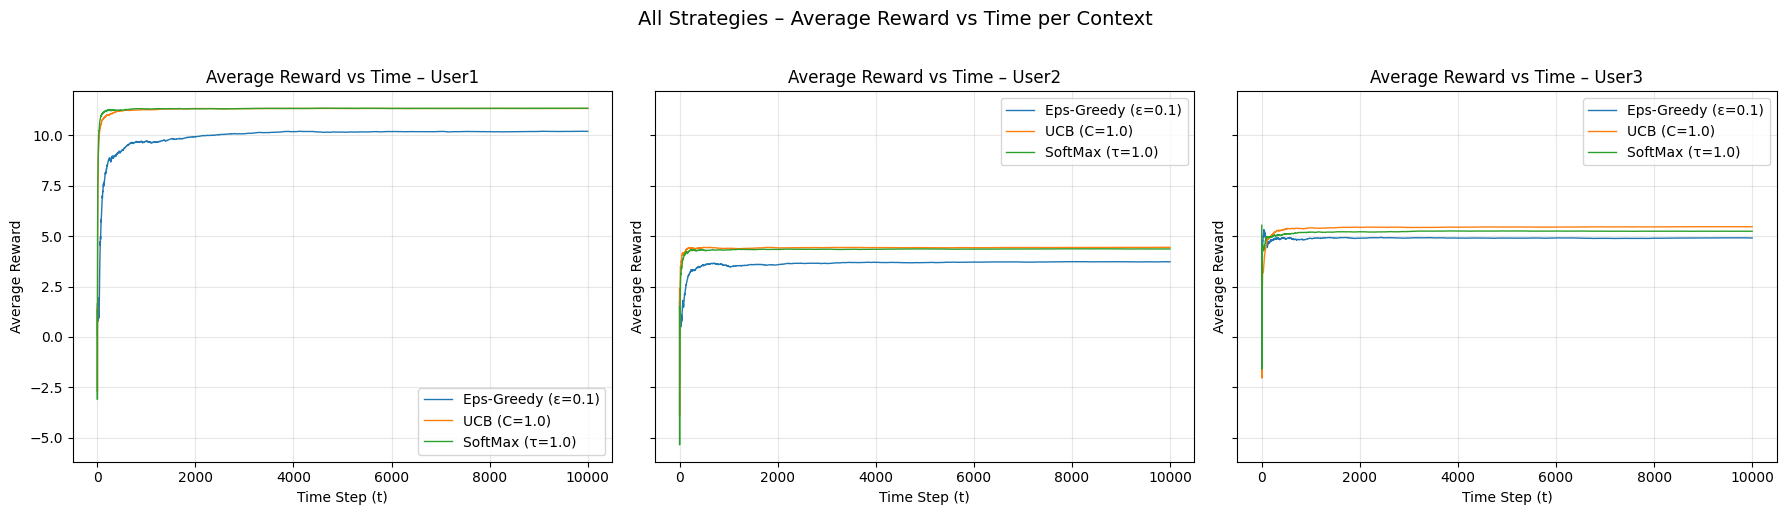

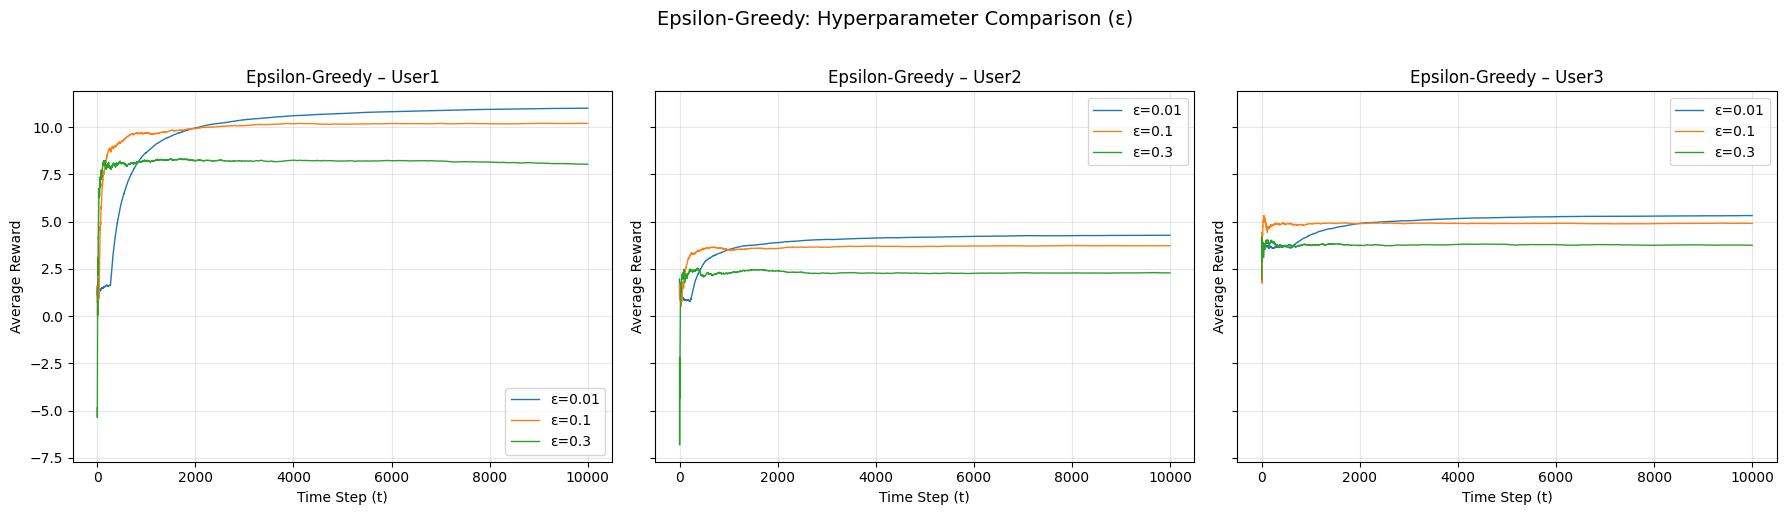

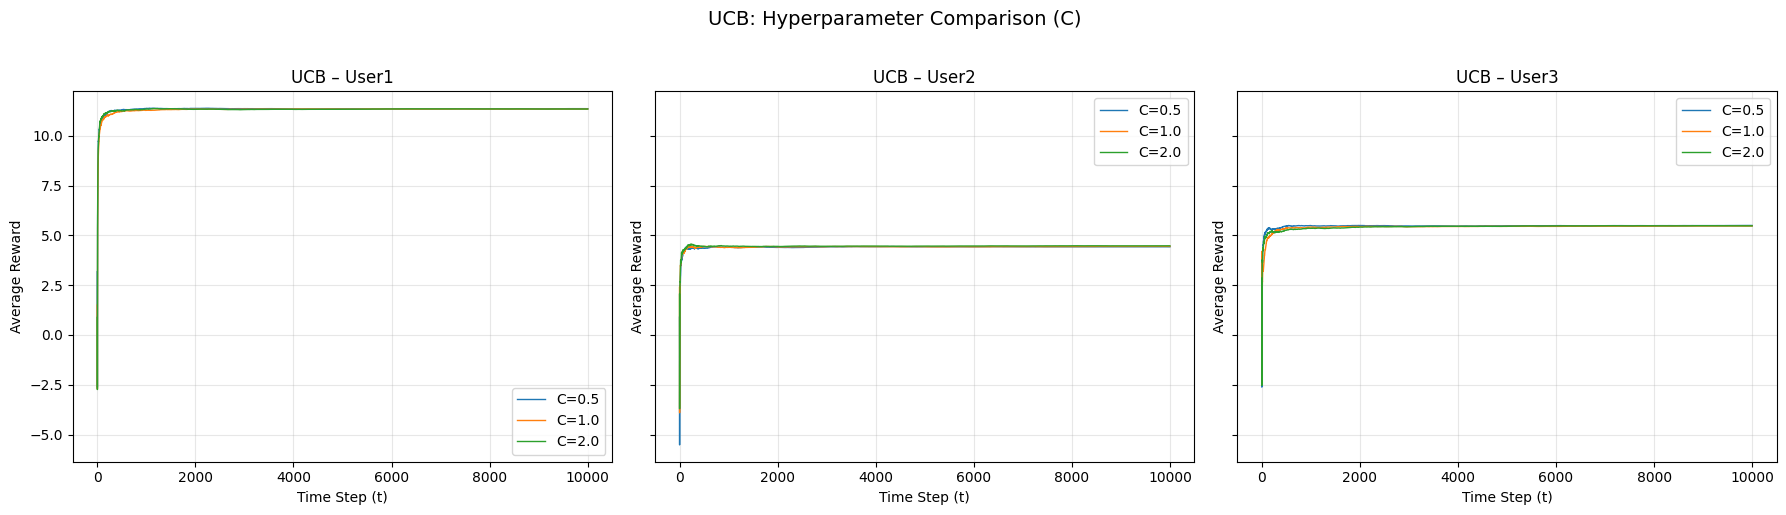

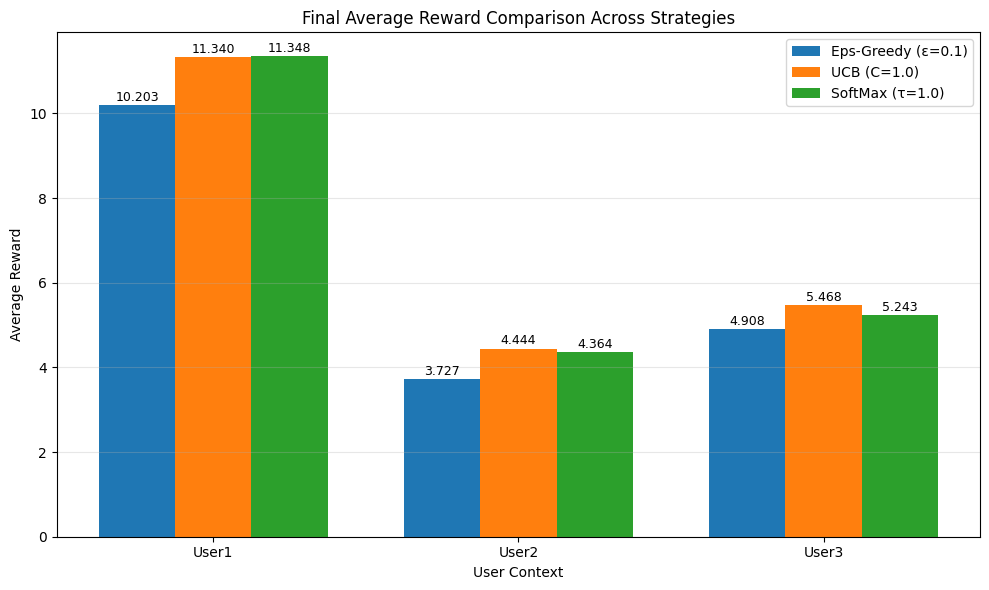

In [90]:
def cumulative_avg(rewards):
    """Compute running average reward."""
    return np.cumsum(rewards) / np.arange(1, len(rewards) + 1)

# ---- 1. Average Reward vs Time for EACH CONTEXT (best hyperparams) ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, ctx in enumerate(CONTEXTS):
    ax = axes[idx]

    # Epsilon-Greedy (eps=0.1)
    avg_r = cumulative_avg(eg_results[0.1][ctx]["rewards"])
    ax.plot(avg_r, label="Eps-Greedy (ε=0.1)", linewidth=1)

    # UCB (C=1.0)
    avg_r = cumulative_avg(ucb_results[1.0][ctx]["rewards"])
    ax.plot(avg_r, label="UCB (C=1.0)", linewidth=1)

    # SoftMax (tau=1)
    avg_r = cumulative_avg(sm_results[ctx]["rewards"])
    ax.plot(avg_r, label="SoftMax (τ=1.0)", linewidth=1)

    ax.set_title(f"Average Reward vs Time – {ctx}")
    ax.set_xlabel("Time Step (t)")
    ax.set_ylabel("Average Reward")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("All Strategies – Average Reward vs Time per Context", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# ---- 2. Epsilon comparison plot ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, ctx in enumerate(CONTEXTS):
    ax = axes[idx]
    for eps in EPSILONS:
        avg_r = cumulative_avg(eg_results[eps][ctx]["rewards"])
        ax.plot(avg_r, label=f"ε={eps}", linewidth=1)
    ax.set_title(f"Epsilon-Greedy – {ctx}")
    ax.set_xlabel("Time Step (t)")
    ax.set_ylabel("Average Reward")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Epsilon-Greedy: Hyperparameter Comparison (ε)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# ---- 3. UCB C comparison plot ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, ctx in enumerate(CONTEXTS):
    ax = axes[idx]
    for c_val in C_VALUES:
        avg_r = cumulative_avg(ucb_results[c_val][ctx]["rewards"])
        ax.plot(avg_r, label=f"C={c_val}", linewidth=1)
    ax.set_title(f"UCB – {ctx}")
    ax.set_xlabel("Time Step (t)")
    ax.set_ylabel("Average Reward")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("UCB: Hyperparameter Comparison (C)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# ---- 4. Summary bar chart: final avg reward per strategy per context ----
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(CONTEXTS))
width = 0.25

eg_avgs = [eg_results[0.1][ctx]["rewards"].mean() for ctx in CONTEXTS]
ucb_avgs = [ucb_results[1.0][ctx]["rewards"].mean() for ctx in CONTEXTS]
sm_avgs = [sm_results[ctx]["rewards"].mean() for ctx in CONTEXTS]

bars1 = ax.bar(x - width, eg_avgs, width, label="Eps-Greedy (ε=0.1)")
bars2 = ax.bar(x, ucb_avgs, width, label="UCB (C=1.0)")
bars3 = ax.bar(x + width, sm_avgs, width, label="SoftMax (τ=1.0)")

ax.set_xlabel("User Context")
ax.set_ylabel("Average Reward")
ax.set_title("Final Average Reward Comparison Across Strategies")
ax.set_xticks(x)
ax.set_xticklabels(CONTEXTS)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 5.4 Recommendation Engine

End-to-end pipeline:
1. **Classify** the user context using the trained classifier.
2. **Select** the best news category using a trained bandit policy.
3. **Recommend** a random article from the selected category.
4. **Output** the article details.

In [91]:
# Build the best policy lookup from bandit results (using eps=0.1 epsilon-greedy)
# For each context, pick the arm (category) with the highest Q-value
best_policy = {}  # context -> best category name
for ctx in CONTEXTS:
    Q = eg_results[0.1][ctx]["Q"]
    best_arm = np.argmax(Q)
    best_policy[ctx] = CATEGORIES[best_arm]

print("Learned Policy (Eps-Greedy, ε=0.1):")
for ctx in CONTEXTS:
    print(f"  {ctx} -> {best_policy[ctx]}")

# Category name mapping for lookup in news_filtered
CATEGORY_MAP = {
    "Entertainment": "ENTERTAINMENT",
    "Education": "EDUCATION",
    "Tech": "TECH",
    "Crime": "CRIME",
}

def recommend_article(user_features):
    """
    Full recommendation pipeline:
    1. Classify user -> context
    2. Look up best news category from bandit policy
    3. Sample a random article from that category
    Returns: (context, category, article_row)
    """
    # Step 1: Classify user context
    context = classify_user(user_features)

    # Step 2: Select best category from learned policy
    category = best_policy[context]

    # Step 3: Sample a random article from that category
    pool = news_filtered[news_filtered["category"] == CATEGORY_MAP[category]]
    article = pool.sample(1).iloc[0]

    return context, category, article


# --- Run on test users ---
test_users_raw = pd.read_csv("data/test_users.csv")

# Apply same preprocessing as training
test_users_raw["age"] = test_users_raw["age"].fillna(age_median)
test_users_raw["subscriber"] = test_users_raw["subscriber"].astype(int)
test_users_raw["region_code"] = test_users_raw["region_code"].apply(
    lambda x: region_encoder.transform([x])[0] if x in region_encoder.classes_ else -1
)

drop_cols = ["user_id", "browser_version"]
test_ids = test_users_raw["user_id"].values
test_users_feat = test_users_raw.drop(columns=drop_cols)

# Show recommendations for first 5 test users
print("\n--- Sample Recommendations (first 5 test users) ---\n")
for i in range(5):
    row = test_users_feat.iloc[i][feature_cols].values
    context, category, article = recommend_article(row)

    print(f"User: {test_ids[i]}")
    print(f"  Predicted Context : {context}")
    print(f"  Recommended Category: {category}")
    print(f"  Article Headline  : {article['headline']}")
    print(f"  Article Link      : {article['link']}")
    print()

Learned Policy (Eps-Greedy, ε=0.1):
  User1 -> Crime
  User2 -> Crime
  User3 -> Crime

--- Sample Recommendations (first 5 test users) ---

User: U4058
  Predicted Context : User2
  Recommended Category: Crime
  Article Headline  : Cops Who Killed Homeless Man Will Stand Trial For Murder
  Article Link      : https://www.huffingtonpost.com/entry/cops-who-killed-homeless-man-in-albuquerque-will-stand-trial-for-murder_us_55d3952ae4b055a6dab1cc82

User: U1118
  Predicted Context : User1
  Recommended Category: Crime
  Article Headline  : DC Police Find 5 Fetuses In Home Of Anti-Abortion Activist Lauren Handy
  Article Link      : https://www.huffpost.com/entry/dc-police-fetuses-anti-abortion-activist-lauren-handy_n_6245e9a5e4b068157f749d7f

User: U6555
  Predicted Context : User1
  Recommended Category: Crime
  Article Headline  : Cassandra Elfers, Middle School Volleyball Coach, Charged With Sex Abuse Of Student
  Article Link      : https://www.huffingtonpost.com/entry/cassandra-elfers

## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


In [99]:
print("=" * 80)
print(f"{'Strategy':<30} {'Context':<10} {'Avg Reward':>12} {'Best Arm':>10} {'Best Cat':>15}")
print("=" * 80)

# Epsilon-Greedy
for eps in EPSILONS:
    for ctx in CONTEXTS:
        r = eg_results[eps][ctx]
        best = np.argmax(r["Q"])
        print(f"Eps-Greedy (ε={eps:<4})       {ctx:<10} {r['rewards'].mean():>12.4f} {best:>10} {CATEGORIES[best]:>15}")
    print("-" * 80)

# UCB
for c_val in C_VALUES:
    for ctx in CONTEXTS:
        r = ucb_results[c_val][ctx]
        best = np.argmax(r["Q"])
        print(f"UCB (C={c_val:<4})              {ctx:<10} {r['rewards'].mean():>12.4f} {best:>10} {CATEGORIES[best]:>15}")
    print("-" * 80)

# SoftMax
for ctx in CONTEXTS:
    r = sm_results[ctx]
    best = np.argmax(r["Q"])
    print(f"SoftMax (τ={TAU})             {ctx:<10} {r['rewards'].mean():>12.4f} {best:>10} {CATEGORIES[best]:>15}")
print("=" * 80)

Strategy                       Context      Avg Reward   Best Arm        Best Cat
Eps-Greedy (ε=0.01)       User1           11.0091          3           Crime
Eps-Greedy (ε=0.01)       User2            4.2803          3           Crime
Eps-Greedy (ε=0.01)       User3            5.3206          3           Crime
--------------------------------------------------------------------------------
Eps-Greedy (ε=0.1 )       User1           10.2027          3           Crime
Eps-Greedy (ε=0.1 )       User2            3.7275          3           Crime
Eps-Greedy (ε=0.1 )       User3            4.9084          3           Crime
--------------------------------------------------------------------------------
Eps-Greedy (ε=0.3 )       User1            8.0424          3           Crime
Eps-Greedy (ε=0.3 )       User2            2.2872          3           Crime
Eps-Greedy (ε=0.3 )       User3            3.7475          3           Crime
---------------------------------------------------------------